# KerrGeodesics.jl: a runnable tutorial

One concept per cell. Run the cells in order: later cells reuse the constants, families and plotting helpers defined earlier. The sections are

0. Loading the package
1. Physical conventions
2. **Classification**: for given $(a, E, L_z, Q)$ the roots of the radial potential decide which orbits exist
3. **Families and members**: `kerr_geodesic` returns every orbit those constants admit
4. **Evaluation**: $t(\lambda),\ r(\lambda),\ \theta(\lambda),\ \phi(\lambda),\ \tau(\lambda)$ and the horizon-regular coordinates $v,\ \psi$
5. Plots
6. One example per class: Stable, Critical, Plunge, Capture, Scatter, Trapped, and the horizon (H) and extremal (X) tiers
7. Polar options
8. The four-velocity, residuals and self-checks
9. The APEX interface $(a, p, e, x)$
10. The 56-case catalogue
11. Batch sampling and performance
12. How the trajectories are computed
13. Accuracy limits

Units $G = c = M = 1$: lengths are in units of the black-hole mass $M$.

## 0. Loading

The figures use `Plots`, which is not a dependency of the package. Install both once:

```julia
import Pkg; Pkg.add(["KerrGeodesics", "Plots"])
```

In [1]:
using KerrGeodesics
using Printf
println("KerrGeodesics loaded.")

KerrGeodesics loaded.


## 1. Physical conventions

A timelike geodesic of Kerr is fixed by three constants of motion: the energy $E$ (per unit mass), the axial angular momentum $L_z$ and the Carter constant $Q$. In Mino time $\lambda$ ($d\tau = \Sigma\, d\lambda$, $\Sigma = r^2 + a^2\cos^2\theta$) the radial and polar motions **separate completely**:

$$
\Big(\frac{dr}{d\lambda}\Big)^2 = R(r) = \big[E(r^2+a^2) - aL_z\big]^2 - \Delta\big[r^2 + (L_z - aE)^2 + Q\big],
\qquad
\Big(\frac{dz}{d\lambda}\Big)^2 = \Theta(z),\quad z = \cos\theta,
$$

$$
\frac{dt}{d\lambda} = \underbrace{\frac{(r^2+a^2)P}{\Delta}}_{T_r(r)} + \underbrace{aL_z - a^2E(1-z^2)}_{T_\theta(z)},\qquad
\frac{d\phi}{d\lambda} = \underbrace{\frac{a(2Er - aL_z)}{\Delta}}_{\Phi_r(r)} + \underbrace{\frac{L_z}{1-z^2}}_{\Phi_\theta(z)},\qquad
\frac{d\tau}{d\lambda} = r^2 + a^2 z^2 ,
$$

with $P = E(r^2+a^2) - aL_z$, $\Delta = r^2 - 2r + a^2$ and horizons $r_\pm = 1 \pm \sqrt{1-a^2}$.

$R(r)$ is a quartic with leading coefficient $E^2 - 1$: for $E<1$ the particle cannot reach infinity, at $E=1$ the quartic degenerates to a cubic, and for $E>1$ it can come from or go to infinity. **Each orbit moves in one connected interval with $R>0$, or sits at a repeated root of $R$ at constant radius**, and one set of constants can admit several. The package sorts them into six classes:

| Class | Letter | Meaning |
|---|---|---|
| Stable | A | stays outside the horizon between two finite radii, or at a constant radius (stable) |
| Critical | K | sits on, or tends asymptotically to, an unstable or marginal repeated root outside the horizon: ISCO/ISSO, unstable circular and spherical orbits, homoclinic orbits, whirls from the root into the horizon, approaches from infinity onto the root |
| Plunge | B | from a finite turning point into the future horizon |
| Capture | C | from infinity into the horizon |
| Scatter | D | from infinity, through a turning point, back to infinity |
| Trapped | N | negative energy, inside the ergoregion: out of the white-hole horizon, through a turning point, into the black-hole horizon |

Besides the numbered cases there are two further tiers: **H** (horizon root, $P(r_+) = 0$, so the horizon itself is a root of $R$, e.g. A-H1, D-H1) and **X** (extremal Kerr, $a = \pm 1$, e.g. B-X1, C-X2).

## 2. From constants to classification

First the lowest-level functions: horizons, the potentials, the root structure.

In [2]:
a, E, Lz, Q = 0.9, 0.94, 0.1, 12.0          # these constants are used throughout

h = kerr_horizons(a)                        # outer and inner horizon
println("r₊ = ", h.rplus, "    r₋ = ", h.rminus)

R(r) = kerr_radial_potential(a, E, Lz, Q, r)       # radial potential R(r)
Θ(z) = kerr_polar_z_potential(a, E, Lz, Q, z)      # polar potential Θ(z), z = cos θ
println("R(5) = ", R(5.0), "     Θ(0.3) = ", Θ(0.3))

r₊ = 1.4358898943540672    r₋ = 0.5641101056459328
R(5) = -9.511940000000068     Θ(0.3) = 10.9113781404


In [3]:
rs = kerr_geo_root_structure(a, E, Lz, Q)   # the roots of R(r), sorted by position
println("real roots (radius, multiplicity): ", [(round(x.radius; digits=6), x.multiplicity) for x in rs.real_roots])
println("real roots outside the horizon:    ", [round(x.radius; digits=6) for x in rs.exterior])
println("real roots inside the horizon:     ", [round(x.radius; digits=6) for x in rs.below_horizon])
println("number of complex roots:           ", rs.complex_root_count)

real roots (radius, multiplicity): [(0.496329, 1), (3.203955, 1)]
real roots outside the horizon:    [3.203955]
real roots inside the horizon:     [0.496329]
number of complex roots:           2


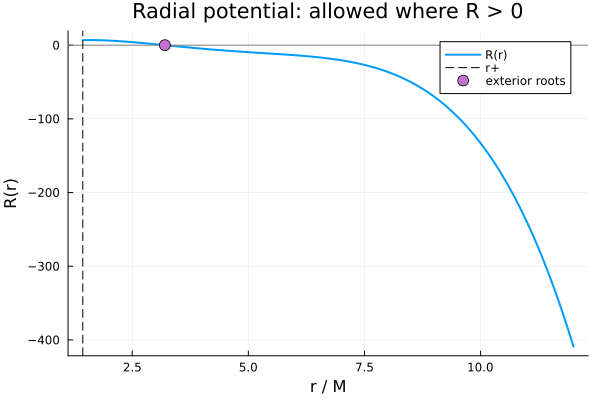

In [4]:
using Plots
rr = range(h.rplus, 12; length=600)
plot(rr, R.(rr); lw=2, label="R(r)", xlabel="r / M", ylabel="R(r)",
     title="Radial potential: allowed where R > 0")
hline!([0.0]; color=:gray, label="")
vline!([h.rplus]; ls=:dash, color=:black, label="r+")
scatter!([x.radius for x in rs.exterior], zeros(length(rs.exterior)); ms=6, label="exterior roots")

**Figure.** The radial potential $R(r)$ (vertical axis) against $r/M$ (horizontal axis) for $a = 0.9$, $(E, L_z, Q) = (0.94, 0.1, 12)$. Motion is allowed where $R \ge 0$; the dashed line is the outer horizon $r_+$ and the dots are the real roots of $R$ outside it.

These constants allow a single interval outside the horizon, $(r_+, r_2]$: the particle falls in from $r_2$. It is a **Plunge** (two real roots and a complex pair, case B4).

`kerr_geo_classify` turns this into cases: one `Component` per allowed interval, with its case ID, class, endpoints and polar sector.

In [5]:
cls = kerr_geo_classify(a, E, Lz, Q)
println("Cases: ", join(string.(cls.CaseIds), ", "))
println("Energy regime: ", cls.EnergyRegime)
println("Case  Class      Radial interval")
for c in cls.Components
    id = something(c.CaseId, :UNASSIGNED)
    @printf("%-5s %-10s [%.4f, %.4f]\n", string(id), string(c.BroadClass),
        c.LowerEndpoint.Radius, c.UpperEndpoint.Radius)
end

Cases: B4
Energy regime: elliptic
Case  Class      Radial interval
B4    plunge     [1.4359, 3.2040]


## 3. Families and members: `kerr_geodesic`

`kerr_geodesic(a, (E, Lz, Q))` is the main entry point. It classifies the constants, builds **every** orbit they admit and puts each in the slot of its class: `Stable`, `Critical` (a tuple), `Plunge`, `Capture`, `Scatter`, `Trapped`. Empty slots are `nothing`.

In [6]:
fam = kerr_geodesic(a, (E, Lz, Q))

KerrGeodesicFamily (constants)
  Constants  = (E = 0.94, Lz = 0.1, Q = 12.0)
  Parameters = (a = 0.9,)
  Plunge     = :B4
  Status     = supported

In [7]:
members = kerr_geo_members(fam);
println("Members: ", join(string.([m.CaseId for m in members]), ", "))
plunge = fam.Plunge;

Members: B4


### What a member contains

Every member is a `KerrGeoComponent{class}` with the same fields:

| Field | Content |
|---|---|
| `CaseId`, `Tier`, `Role` | case ID; tier (`:primary` / `:horizon` / `:extremal`); for Critical members, the side of the repeated root (`:on_root`, `:outer`, `:inner`) |
| `ConstantsOfMotion` | `(a, E, Lz, Q)` |
| `Roots` | radial roots and polar metadata |
| `Domain` | the Mino-time domain `mino = (λ_lo, λ_hi)` and its endpoint roles |
| `ReferenceZero` | where $\lambda$, $t,\phi$, $\tau$ (and $v,\psi$) are zero |
| `Trajectory` | functions of $\lambda$: `t r theta z phi tau`, plus `rstar v psi` for members that reach a horizon |
| `Velocity` | Mino-time rates `ut ur uz utheta uphi`, and `dtau_dlambda` $=\Sigma$ |
| `Potentials`, `Residuals` | $R(r)$, $\Theta(z)$; the residuals of the geodesic equations |
| `Status` | support flag, formula family, polar metadata, accuracy of the spectral tables, member-specific data |

In [8]:
m = fam.Plunge

KerrGeoPlungeComponent (B4)
  Constants  = (a = 0.9, E = 0.94, Lz = 0.1, Q = 12.0)
  Tier       = :primary
  Mino time  = (0.0, 1.11607)
  Trajectory = (t(lambda), r(lambda), theta(lambda), phi(lambda))
  Status     = supported

## 4. Evaluation

The trajectory functions are ordinary Julia functions of $\lambda$. The domain of this Plunge member is $[0, \lambda_H]$: $\lambda = 0$ is the outer turning point and $\lambda_H$ the horizon. Boyer–Lindquist $t,\phi$ diverge on the horizon, so they do not accept $\lambda_H$ itself; the advanced coordinates $v = t + r_*$ and $\psi = \phi + \phi_H$ are finite there and accept the endpoint.

In [9]:
tr = m.Trajectory
lo, hi = m.Domain.mino
λ = 0.3 * hi
@printf("t     = %.6g\n", tr.t(λ))
@printf("r     = %.6g\n", tr.r(λ))
@printf("theta = %.6g\n", tr.theta(λ))
@printf("phi   = %.6g\n", tr.phi(λ))

t     = 7.96432
r     = 3.03116
theta = 0.412975
phi   = 0.463921


In [10]:
# Outside the domain, no trajectory value is returned.
try
    tr.r(hi + 1.0)
catch err
    println("Outside domain: ", typeof(err))
end
# Regular coordinates remain defined at the future horizon.
@printf("At horizon: r = %.6g, v = %.6g, psi = %.6g\n", tr.r(hi), tr.v(hi), tr.psi(hi))

Outside domain: DomainError
At horizon: r = 1.43589, v = 0, psi = 0


In [11]:
# Two events, with the same four coordinate calls.
@printf("%12s %12s %12s %12s\n", "t", "r", "theta", "phi")
for λ in (0.0, hi / 2)
    @printf("%12.6g %12.6g %12.6g %12.6g\n", tr.t(λ), tr.r(λ), tr.theta(λ), tr.phi(λ))
end

           t            r        theta          phi
           0      3.20396       1.5708            0
     13.1365      2.72608      0.35977      3.78065


## 5. Plots

Three helpers used below: Boyer–Lindquist to Cartesian-like coordinates ($x = \sqrt{r^2+a^2}\sin\theta\cos\phi$ etc., Kerr–Schild type), sample points inside the domain (infinite ends cut off), and a member drawn in its $x$–$y$ and $x$–$z$ projections.

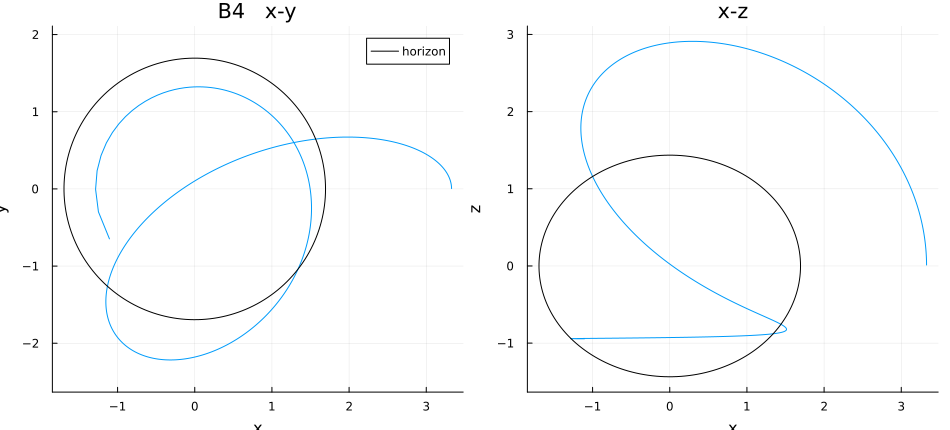

In [12]:
using Plots

bl_to_xyz(a, r, θ, φ) = (ρ = sqrt(r^2 + a^2); (ρ*sin(θ)*cos(φ), ρ*sin(θ)*sin(φ), r*cos(θ)))

# sample points inside the domain: infinite ends are cut at `span`, both ends keep a `margin`,
# points beyond `rmax` (the far ends of scatter and capture orbits) are dropped
function lambda_grid(m; n=3000, span=40.0, margin=1e-3, rmax=Inf)
    lo, hi = m.Domain.mino
    isfinite(lo) || (lo = isfinite(hi) ? hi - span : -span/2)
    isfinite(hi) || (hi = lo + span)
    w = hi - lo
    λs = collect(range(lo + margin*w, hi - margin*w; length=n))
    return isfinite(rmax) ? filter(λ -> m.Trajectory.r(λ) <= rmax, λs) : λs
end

function plot_member(m; λs=lambda_grid(m; rmax=60.0), title=string(kerr_geo_case_name(m.CaseId)))
    a = m.ConstantsOfMotion.a
    s = kerr_geo_sample(m, λs)
    xyz = bl_to_xyz.(a, s.r, s.theta, s.phi)
    x, y, z = first.(xyz), getindex.(xyz, 2), last.(xyz)
    rp = kerr_horizons(a).rplus; ρp = sqrt(rp^2 + a^2)
    c = range(0, 2π; length=200)
    p1 = plot(x, y; aspect_ratio=1, lw=1, label="", xlabel="x", ylabel="y", title=title * "   x-y")
    plot!(p1, ρp .* cos.(c), ρp .* sin.(c); color=:black, label="horizon")
    p2 = plot(x, z; aspect_ratio=1, lw=1, label="", xlabel="x", ylabel="z", title="x-z")
    plot!(p2, ρp .* cos.(c), rp .* sin.(c); color=:black, label="")
    plot(p1, p2; layout=(1, 2), size=(950, 430))
end

plot_member(fam.Plunge)

**Figure.** The Plunge member B4 of $a = 0.9$, $(E, L_z, Q) = (0.94, 0.1, 12)$, from its turning point $r_2$ into the horizon. Left: the $x$–$y$ plane; right: the $x$–$z$ plane, with $x = \sqrt{r^2+a^2}\sin\theta\cos\phi$, $y = \sqrt{r^2+a^2}\sin\theta\sin\phi$, $z = r\cos\theta$ (units of $M$, spin along $z$); the black curve is the outer horizon $r = r_+$.

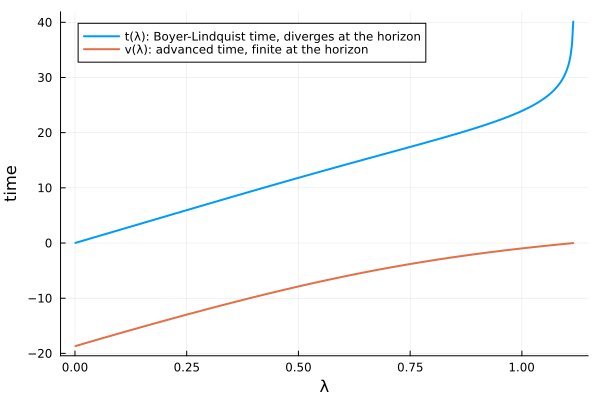

In [13]:
# Boyer–Lindquist t diverges on the horizon while the advanced time v stays finite: members
# that reach a horizon therefore give both
λs = lambda_grid(m; n=400)
plot(λs, tr.t.(λs); lw=2, label="t(λ): Boyer-Lindquist time, diverges at the horizon", xlabel="λ", ylabel="time")
plot!(λs, tr.v.(λs); lw=2, label="v(λ): advanced time, finite at the horizon")

**Figure.** The same B4 member: Boyer–Lindquist time $t(\lambda)$ and advanced time $v(\lambda) = t + r_*$ (vertical axis) against Mino time $\lambda$ (horizontal axis) over its domain $[0, \lambda_H)$. $t$ grows without bound as $\lambda \to \lambda_H$ (the horizon); $v$ stays finite and is zero there.

## 6. One example per class

### 6.1 Stable (class A), and its Plunge partner with the same constants

Stable orbits are usually described by the APEX parameters $(a, p, e, x)$: spin, semi-latus rectum, eccentricity and $\cos$(inclination). `kerr_geo_constants_of_motion` turns them into constants for `kerr_geodesic`; `kerr_geodesic(a, p, e, x)` does both in one call.

In [14]:
aA, pA, eA, xA = 0.9, 10.0, 0.5, 0.8
cA = kerr_geo_constants_of_motion(aA, pA, eA, xA)        # a Dict
EA, LA, QA = cA["E"], cA["Lz"], cA["Q"]
println("E = $EA   Lz = $LA   Q = $QA")
famA = kerr_geodesic(aA, (EA, LA, QA))
println("members: ", [m.CaseId for m in kerr_geo_members(famA)],
    "   (the same constants: a Stable orbit A1 and, closer in, a Plunge B1)")

E = 0.9641204328952225   Lz = 2.8359152778998347   Q = 4.544408272395791
members: [:A1, :B1]   (the same constants: a Stable orbit A1 and, closer in, a Plunge B1)


Mino frequencies: radial = 2.79272, polar = 3.55149
Mean rates: time = 171.093, azimuth = 3.73576
Periods: radial = 2.24984, polar = 1.76917


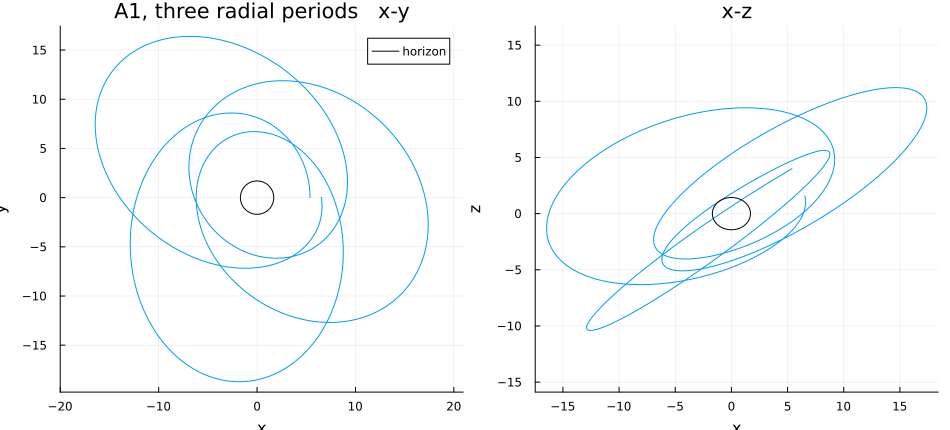

In [15]:
s = famA.Stable
Υ = s.Status.frequencies
@printf("Mino frequencies: radial = %.6g, polar = %.6g\n", Υ.ϒr, Υ.ϒθ)
@printf("Mean rates: time = %.6g, azimuth = %.6g\n", Υ.ϒt, Υ.ϒϕ)
@printf("Periods: radial = %.6g, polar = %.6g\n", 2π / Υ.ϒr, 2π / Υ.ϒθ)
plot_member(s; λs=range(0, 3 * 2π / Υ.ϒr; length=4000), title="A1, three radial periods")

**Figure.** The Stable member A1 of the APEX orbit $(a, p, e, x) = (0.9, 10, 0.5, 0.8)$, drawn over three radial periods $\lambda \in [0, 3\cdot 2\pi/\Upsilon_r]$. Left: the $x$–$y$ plane; right: the $x$–$z$ plane, with $x = \sqrt{r^2+a^2}\sin\theta\cos\phi$, $y = \sqrt{r^2+a^2}\sin\theta\sin\phi$, $z = r\cos\theta$ (units of $M$, spin along $z$); the black curve is the outer horizon $r = r_+$.

Orbit B1: Mino-time interval [0, 0.054266]


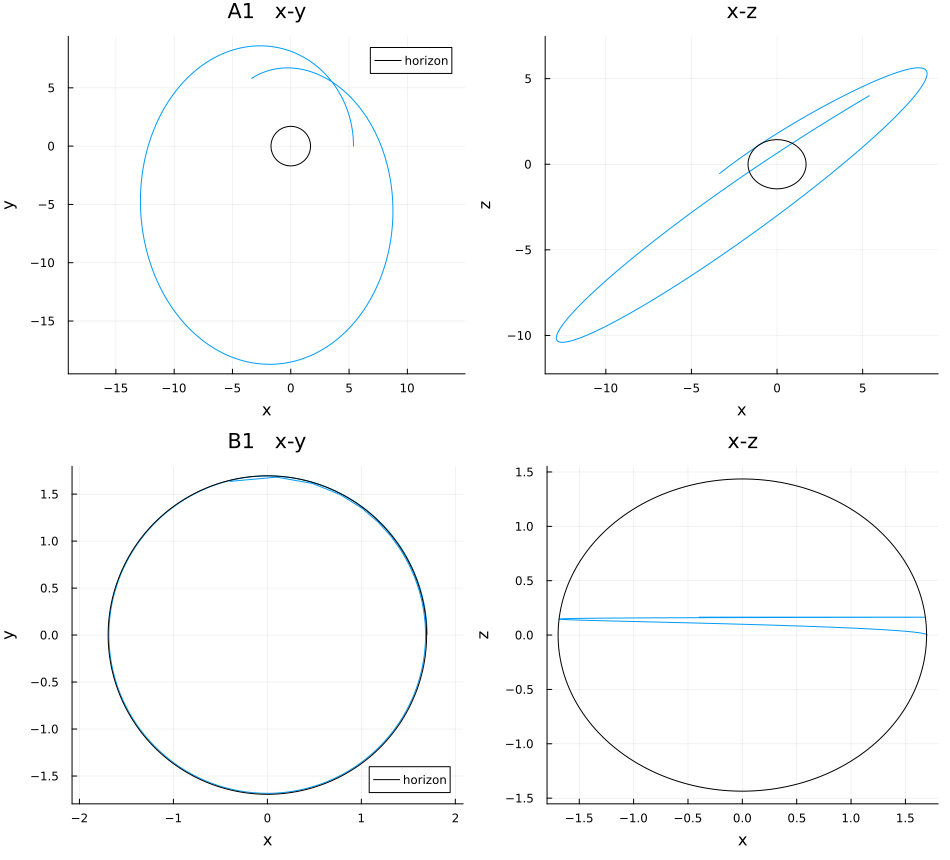

In [16]:
# The inner plunge shares its constants with the stable member.
b = famA.Plunge
@printf("Orbit %s: Mino-time interval [%.6g, %.6g]\n", string(b.CaseId), b.Domain.mino...)
plot(plot_member(s; λs=range(0, 2π/Υ.ϒr; length=2000), title="A1"), plot_member(b; title="B1"); layout=(2, 1), size=(950, 860))

**Figure.** Top: the A1 member of $(a, p, e, x) = (0.9, 10, 0.5, 0.8)$ over one radial period. Bottom: the Plunge B1 of the same constants, from the inner turning point into the horizon. Left: the $x$–$y$ plane; right: the $x$–$z$ plane, with $x = \sqrt{r^2+a^2}\sin\theta\cos\phi$, $y = \sqrt{r^2+a^2}\sin\theta\sin\phi$, $z = r\cos\theta$ (units of $M$, spin along $z$); the black curve is the outer horizon $r = r_+$.

### 6.2 Critical (class K): homoclinic orbit, unstable spherical orbit, whirling plunge

An unstable double root $r_c$ outside the horizon comes with three members: the spherical orbit sitting on $r_c$ (K3, `Role == :on_root`), the homoclinic orbit that leaves $r_c$ asymptotically, reaches apastron and returns (K4, `:outer`: the separatrix of zoom-whirl orbits), and the whirling plunge from $r_c$ into the horizon (K5, `:inner`). The family's `Critical` slot holds this tuple (`famK.Critical` below).

In [17]:
famK = kerr_geodesic(0.5, (0.9460848987210302, 0.6845036824416039, 11.270268598085659))
println("Case  Role       r(0)")
for k in famK.Critical
    @printf("%-5s %-10s %.6g\n", string(k.CaseId), string(k.Role), k.Trajectory.r(0.0))
end

Case  Role       r(0)
K3    on_root    4.5
K4    outer      9.92796
K5    inner      1.86603


plotting K4, role outer


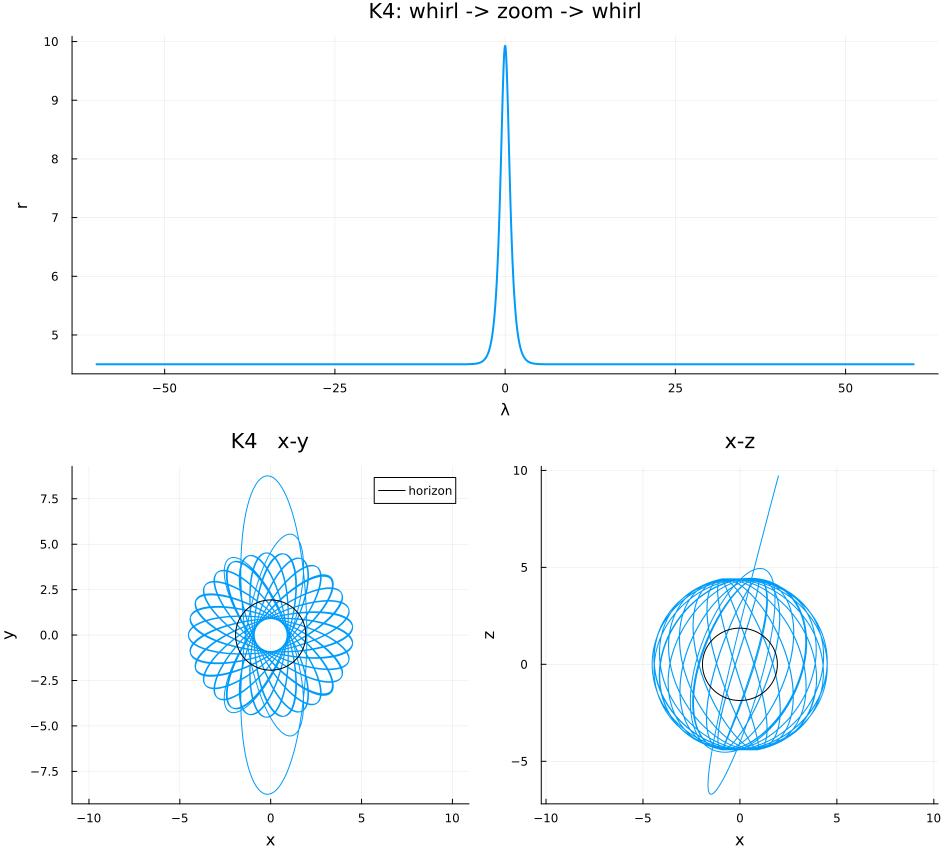

In [18]:
k4 = famK.Critical[2]        # fixed order: on the root, outer side (homoclinic), inner side (into the horizon); λ = 0 at apastron
println("plotting ", k4.CaseId, ", role ", k4.Role)
λs = range(-60, 60; length=6000)
p1 = plot(λs, k4.Trajectory.r.(λs); lw=2, xlabel="λ", ylabel="r", label="", title="K4: whirl -> zoom -> whirl")
p2 = plot_member(k4; λs=λs, title="K4")
plot(p1, p2; layout=(2, 1), size=(950, 860))

**Figure.** The homoclinic Critical member K4 of $a = 0.5$, $(E, L_z, Q) = (0.94608, 0.68450, 11.27027)$. Top: $r(\lambda)$ against Mino time $\lambda \in [-60, 60]$, with apastron at $\lambda = 0$ and $r \to r_c$ (the unstable spherical orbit) as $\lambda \to \pm\infty$. Bottom: the orbit in space. Left: the $x$–$y$ plane; right: the $x$–$z$ plane, with $x = \sqrt{r^2+a^2}\sin\theta\cos\phi$, $y = \sqrt{r^2+a^2}\sin\theta\sin\phi$, $z = r\cos\theta$ (units of $M$, spin along $z$); the black curve is the outer horizon $r = r_+$.

In [19]:
# The Schwarzschild ISCO is a triple radial root at r = 6.
famI = kerr_geodesic(0.0, (sqrt(8/9), sqrt(12.0), 0.0))
for k in famI.Critical
    @printf("%s: role = %s, r(0) = %.6g\n", string(k.CaseId), string(k.Role), k.Trajectory.r(0.0))
end

K1: role = on_root, r(0) = 6
K2: role = inner, r(0) = 2


### 6.3 Capture (class C): from infinity into the horizon

The domain of this member is $(\lambda_{-\infty}, 0]$: $r \to \infty$ as $\lambda \to \lambda_{-\infty}$, and $\lambda = 0$ is the horizon, where $\tau = v = \psi = 0$. The Mino time to infinity is finite.

Orbit C1: Mino-time interval [-1.07826, 0]
Near infinity: r = 2e+12
At horizon: r = 1.86603


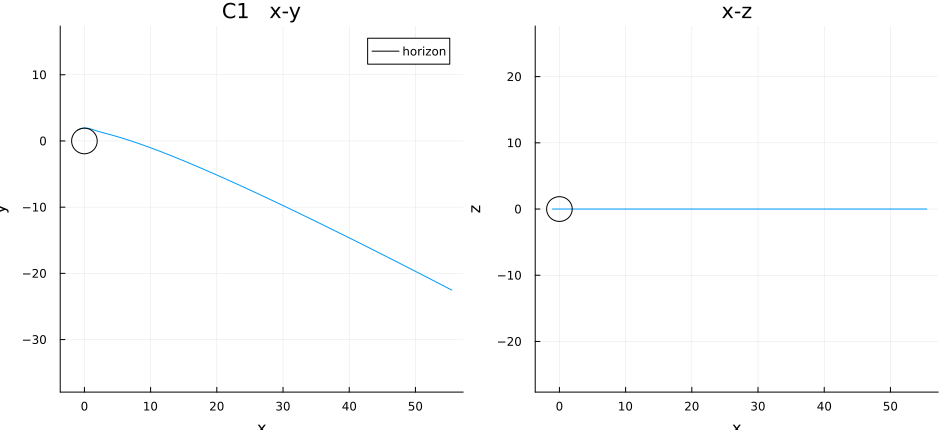

In [20]:
famC = kerr_geodesic(0.5, (1.0, 1.0, 0.0))
c1 = famC.Capture
lo, hi = c1.Domain.mino
@printf("Orbit %s: Mino-time interval [%.6g, %.6g]\n", string(c1.CaseId), lo, hi)
@printf("Near infinity: r = %.6g\nAt horizon: r = %.6g\n", c1.Trajectory.r(lo + 1e-6), c1.Trajectory.r(0.0))
plot_member(c1; title="C1")

**Figure.** The equatorial Capture member C1 of $a = 0.5$, $(E, L_z, Q) = (1, 1, 0)$, from infinity (cut at $r = 60$) into the horizon. Left: the $x$–$y$ plane; right: the $x$–$z$ plane, with $x = \sqrt{r^2+a^2}\sin\theta\cos\phi$, $y = \sqrt{r^2+a^2}\sin\theta\sin\phi$, $z = r\cos\theta$ (units of $M$, spin along $z$); the black curve is the outer horizon $r = r_+$.

### 6.4 Scatter (class D): from infinity, back to infinity

The domain is $(\lambda_{-\infty}, \lambda_{+\infty})$ with $\lambda = 0$ at closest approach. The same constants also admit a plunge closer in (D1 and B5 are partners).

Members: B5, D1
Closest approach: r = 7.71105
Azimuthal change across this window: 6.21756 rad


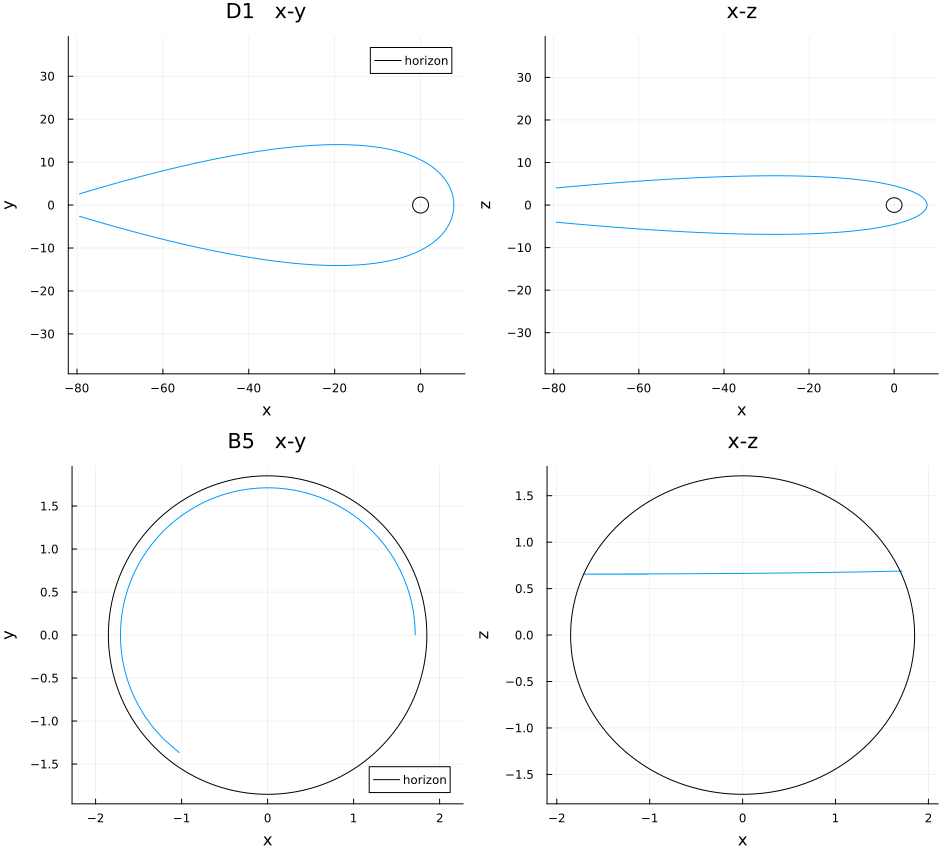

In [21]:
famD = kerr_geodesic(0.7, (1.0, 4.0, 3.0))
d1, b5 = famD.Scatter, famD.Plunge
println("Members: ", join(string.([m.CaseId for m in kerr_geo_members(famD)]), ", "))
@printf("Closest approach: r = %.6g\n", d1.Trajectory.r(0.0))
λs = lambda_grid(d1; rmax=80.0)
@printf("Azimuthal change across this window: %.6g rad\n", d1.Trajectory.phi(λs[end]) - d1.Trajectory.phi(λs[1]))
plot(plot_member(d1; λs=λs, title="D1"), plot_member(b5; title="B5"); layout=(2, 1), size=(950, 860))

**Figure.** Top: the Scatter member D1 of $a = 0.7$, $(E, L_z, Q) = (1, 4, 3)$, in from infinity to closest approach at $\lambda = 0$ and out again (cut at $r = 80$). Bottom: the Plunge B5 of the same constants. Left: the $x$–$y$ plane; right: the $x$–$z$ plane, with $x = \sqrt{r^2+a^2}\sin\theta\cos\phi$, $y = \sqrt{r^2+a^2}\sin\theta\sin\phi$, $z = r\cos\theta$ (units of $M$, spin along $z$); the black curve is the outer horizon $r = r_+$.

### 6.5 Trapped (class N): negative energy

These exist only inside the ergoregion. The domain is $[-\lambda_H, \lambda_H]$: $-\lambda_H$ on the past (white-hole) horizon, $0$ at the turning point, $\lambda_H$ on the future horizon. Each half has its own regular chart: retarded coordinates $(u, \chi)$ on the past half, advanced coordinates $(v, \psi)$ on the future half.

Orbit N4: Mino-time interval [-0.11183, 0.11183]
Radius: past horizon = 1.48796, turning point = 1.68519, future horizon = 1.48796
Regular times: u(-0.3 lambda_H) = 1.7035, v(0.3 lambda_H) = -1.7035


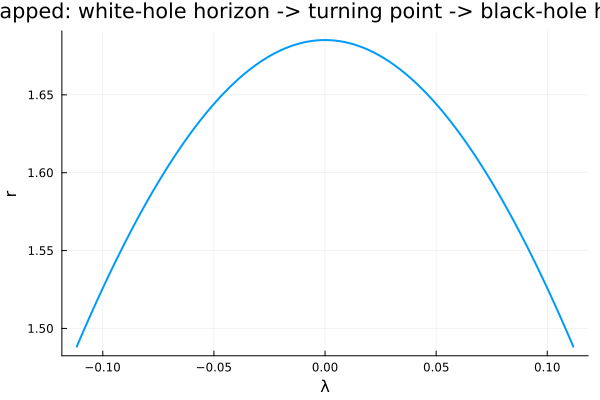

In [22]:
famN = kerr_geodesic(0.8728659559448082, (-0.33168627628550973, -4.969977565843738, 17.959132393955606))
n = famN.Trapped
λH = n.Domain.mino[2]
@printf("Orbit %s: Mino-time interval [%.6g, %.6g]\n", string(n.CaseId), n.Domain.mino...)
@printf("Radius: past horizon = %.6g, turning point = %.6g, future horizon = %.6g\n",
    n.Trajectory.r(-λH), n.Trajectory.r(0.0), n.Trajectory.r(λH))
@printf("Regular times: u(-0.3 lambda_H) = %.6g, v(0.3 lambda_H) = %.6g\n",
    n.Trajectory.u(-0.3λH), n.Trajectory.v(0.3λH))
λs = range(-λH, λH; length=2000)[2:end-1]
plot(λs, n.Trajectory.r.(λs); lw=2, xlabel="λ", ylabel="r", label="", title="Trapped: white-hole horizon -> turning point -> black-hole horizon")

**Figure.** The Trapped member of $a = 0.87287$, $(E, L_z, Q) = (-0.33169, -4.96998, 17.95913)$: $r(\lambda)$ (vertical axis) against Mino time $\lambda \in (-\lambda_H, \lambda_H)$ (horizontal axis), from the past horizon through the turning point at $\lambda = 0$ to the future horizon; both ends are at $r_+$.

### 6.6 The H and X tiers

**H**: $L_z$ makes $P(r_+) = 0$ exactly, so the horizon itself is a root of $R$ and the general formulas degenerate there. **X**: $a = \pm 1$, where the two horizons coincide. Their `Tier` is `:horizon` and `:extremal`; their display names use a hyphen (`kerr_geo_case_name`).

H tier: A_H1 → display name A-H1   Tier = horizon   domain (-Inf, Inf)
X tier: B_X1 → display name B-X1   Tier = extremal   domain (-Inf, Inf)


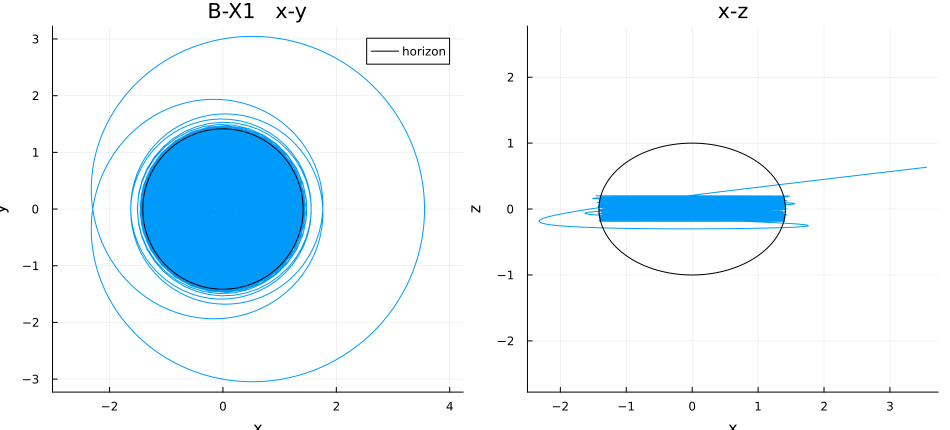

In [23]:
famH = kerr_geodesic(0.9, (0.94, 2.9994144459840513, 0.0))       # Lz with P(r₊) = 0: the horizon is a root of R
mH = kerr_geo_members(famH)[1]
println("H tier: ", mH.CaseId, " → display name ", kerr_geo_case_name(mH.CaseId), "   Tier = ", mH.Tier, "   domain ", mH.Domain.mino)

famX = kerr_geodesic(1.0, (0.8, 1.6, 0.1))                          # a plunge in extremal Kerr
mX = first(kerr_geo_members(famX))
println("X tier: ", mX.CaseId, " → display name ", kerr_geo_case_name(mX.CaseId), "   Tier = ", mX.Tier, "   domain ", mX.Domain.mino)
plot_member(mX)

**Figure.** The extremal-tier member B-X1 of $a = 1$, $(E, L_z, Q) = (0.8, 1.6, 0.1)$, for which $P(r_+) = 2E - aL_z = 0$. Left: the $x$–$y$ plane; right: the $x$–$z$ plane, with $x = \sqrt{r^2+a^2}\sin\theta\cos\phi$, $y = \sqrt{r^2+a^2}\sin\theta\sin\phi$, $z = r\cos\theta$ (units of $M$, spin along $z$); the black curve is the outer horizon $r = r_+$.

## 7. Polar options

The polar motion has sectors set by $Q$ and $L_z$: $Q>0$ pendular, $Q=0$ equatorial, $Q<0$ with $E>1$ vortical (the orbit stays in one hemisphere), $L_z=0$ crossing the axis. Keywords:

- `polar_phase`: the polar phase at the member's reference event (default 0); what phase 0 means depends on the sector and is recorded in `ReferenceZero.polar_phase_convention` (for the Plunge above: the equator, moving north)
- `polar_hemisphere`: `:north` / `:south` for vortical motion
- `polar_sector`: the sector, when the constants do not fix it

Orbit: C5; polar sector: vortical


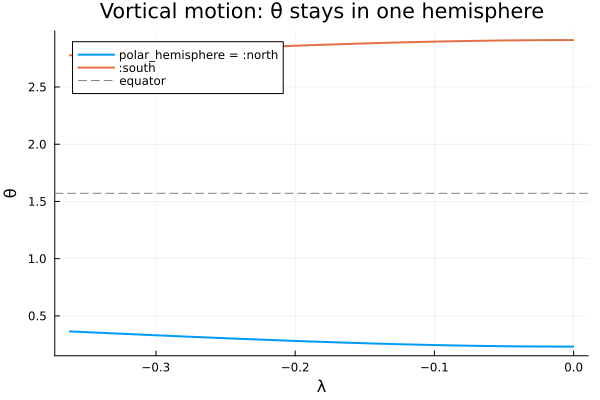

In [24]:
famV = kerr_geodesic(0.9, (1.8, 0.2, -1.0))
v = famV.Capture
println("Orbit: ", v.CaseId, "; polar sector: ", v.Roots.polar.sector)
λs = lambda_grid(v; rmax=40.0)
plot(λs, v.Trajectory.theta.(λs); lw=2, xlabel="λ", ylabel="θ", label="polar_hemisphere = :north", title="Vortical motion: θ stays in one hemisphere")
famVs = kerr_geodesic(0.9, (1.8, 0.2, -1.0); polar_hemisphere=:south)
plot!(λs, famVs.Capture.Trajectory.theta.(λs); lw=2, label=":south")
hline!([π/2]; color=:gray, ls=:dash, label="equator")

**Figure.** The polar angle $\theta(\lambda)$ (vertical axis, radians) against Mino time $\lambda$ (horizontal axis) for the vortical Capture member C5 of $a = 0.9$, $(E, L_z, Q) = (1.8, 0.2, -1)$, in the northern and in the southern hemisphere (`polar_hemisphere`); the dashed line is the equator $\theta = \pi/2$.

In [25]:
# the same orbit with another polar phase: θ(0) changes, r(λ) does not
fam0 = kerr_geodesic(a, (E, Lz, Q))
fam1 = kerr_geodesic(a, (E, Lz, Q); polar_phase=1.0)
(θ0 = fam0.Plunge.Trajectory.theta(0.0), θ1 = fam1.Plunge.Trajectory.theta(0.0),
 r0 = fam0.Plunge.Trajectory.r(0.2), r1 = fam1.Plunge.Trajectory.r(0.2))

(θ0 = 1.5707963267948968, θ1 = 0.5725174054584962, r0 = 3.1422536096282934, r1 = 3.1422536096282934)

## 8. Four-velocity, residuals and self-checks

`Velocity` holds the Mino-time derivatives $dx^\mu/d\lambda$; dividing by $\Sigma = $ `dtau_dlambda` gives the four-velocity $u^\mu = dx^\mu/d\tau$. `Residuals` are the residuals of three identities, $(dr/d\lambda)^2 - R$, $(dz/d\lambda)^2 - \Theta$ and $g_{\mu\nu}u^\mu u^\nu + 1$; each vanishes to rounding error relative to the size of its terms. The radial rate is $\pm\sqrt{R(r(\lambda))}$, so these identities test the velocity at the computed point; the trajectory itself is tested by finite differences in the next two cells.

In [26]:
m = famA.Stable; vel = m.Velocity; λ = 1.7
Σ = vel.dtau_dlambda(λ)
u_mino = (vel.ut(λ), vel.ur(λ), vel.utheta(λ), vel.uphi(λ))
u_proper = u_mino ./ Σ
@printf("%14s %11s %11s %11s %11s\n", "", "t", "r", "theta", "phi")
@printf("%14s %11.6g %11.6g %11.6g %11.6g\n", "dx/dlambda", u_mino...)
@printf("%14s %11.6g %11.6g %11.6g %11.6g\n", "dx/dtau", u_proper...)
@printf("Residuals: radial = %.3g, polar = %.3g, norm = %.3g\n",
    m.Residuals.radial(λ), m.Residuals.polar_z(λ), m.Residuals.normalization(λ))

                         t           r       theta         phi
    dx/dlambda     111.696    -12.7781   -0.636786     4.48335
       dx/dtau     1.20945   -0.138362 -0.00689515   0.0485459
Residuals: radial = 2.84e-14, polar = -5e-16, norm = 4.44e-16


In [27]:
# check it by hand: the finite-difference dr/dλ against √R
h = 1e-5
dr = (m.Trajectory.r(λ + h) - m.Trajectory.r(λ - h)) / 2h
println("finite difference (dr/dλ)² = ", dr^2, "    R(r(λ)) = ", m.Potentials.radial(m.Trajectory.r(λ)))

finite difference (dr/dλ)² = 163.2795807199023    R(r(λ)) = 163.27958068466467


In [28]:
d = kerr_geo_diagnose(fam.Plunge; a=a, E=E, Lz=Lz, Q=Q)
println("Checks passed: ", d.ok)
@printf("Relative discrepancies: r = %.3g, z = %.3g, t = %.3g, phi = %.3g\n",
    d.radial, d.polar, d.time, d.azimuth)

Checks passed: true
Relative discrepancies: r = 1.88e-11, z = 5.29e-12, t = 6.55e-12, phi = 6.89e-12


In [29]:
for d in kerr_geo_diagnose(famA)
    println("Member ", d.member, ": checks passed = ", d.ok)
end

Member A1: checks passed = true
Member B1: checks passed = true


## 9. The APEX interface

Functions with $(a, p, e, x)$ input, ported from the Mathematica KerrGeodesics package. `kerr_geo_orbit`, `kerr_geo_constants_of_motion` and `kerr_geo_frequencies` return a `Dict`; the landmark functions return a number (a radius, or the separatrix value of $p$). `kerr_geo_orbit` covers stable orbits, constant-radius Critical orbits with $E < 1$ (ISCO/ISSO, unstable circular and spherical orbits); for any other $(a, p, e, x)$ it throws an `ArgumentError` that names the orbit's class and points to `kerr_geodesic` (for example `kerr_geodesic(a, p, e, x).Scatter` when $e > 1$).

In [30]:
o = kerr_geo_orbit(0.9, 10.0, 0.5, 0.8)
t_, r_, θ_, ϕ_ = o["Trajectory"]
@printf("t     = %.6g\n", t_(1.0))
@printf("r     = %.6g\n", r_(1.0))
@printf("theta = %.6g\n", θ_(1.0))
@printf("phi   = %.6g\n", ϕ_(1.0))

t     = 141.091
r     = 18.7577
theta = 2.15356
phi   = 3.83559


In [31]:
kerr_geo_frequencies(0.9, 10.0, 0.5, 0.8; Time="BoyerLindquist")   # also "Mino" and "Proper"

Dict{String, Float64} with 3 entries:
  "Ωr" => 0.0163229
  "Ωθ" => 0.0207577
  "Ωϕ" => 0.0218347

In [32]:
# a few landmark radii
(isco = kerr_geo_isco(0.9, 1.0),            # prograde equatorial ISCO (x = cos ι = 1)
 isso = kerr_geo_isso(0.9, 0.8),            # inclined ISSO
 ibso = kerr_geo_ibso(0.9, 0.8),            # innermost spherical orbit with E = 1 (IBSO)
 sep  = kerr_geo_separatrix(0.9, 0.5, 0.8)) # the separatrix p for given e, x

(isco = 2.320883041761887, isso = 2.7942192618175166, ibso = 1.9561822403289237, sep = 3.3171758946127854)

In [33]:
window = kerr_geo_plunge(a, E, Lz, Q)
@printf("Finite-window r(0.5) = %.6g\n", window.Trajectory.r(0.5))

Finite-window r(0.5) = 2.81963


## 10. The 56-case catalogue

`example/kerr_geodesics_56_case_support.jl` holds one example parameter set for every case and tier member; the animations in the README are rendered from them. Run this notebook from the `example` directory so that the file is found.

In [34]:
include("kerr_geodesics_56_case_support.jl")
println("Class      Examples")
for cls in (:stable, :critical, :plunge, :capture, :scatter, :trapped)
    count_in_class = count(fx -> fx.broad_class == cls, KG56_EXAMPLES)
    @printf("%-10s %3d\n", string(cls), count_in_class)
end

Class      Examples
stable       6
critical    11
plunge      11
capture     16
scatter      6
trapped      6


parameters: a = 0.9  E = 1.0  Lz = 3.190866431897927  Q = 0.0   motion: parabolic horizon-root scatter


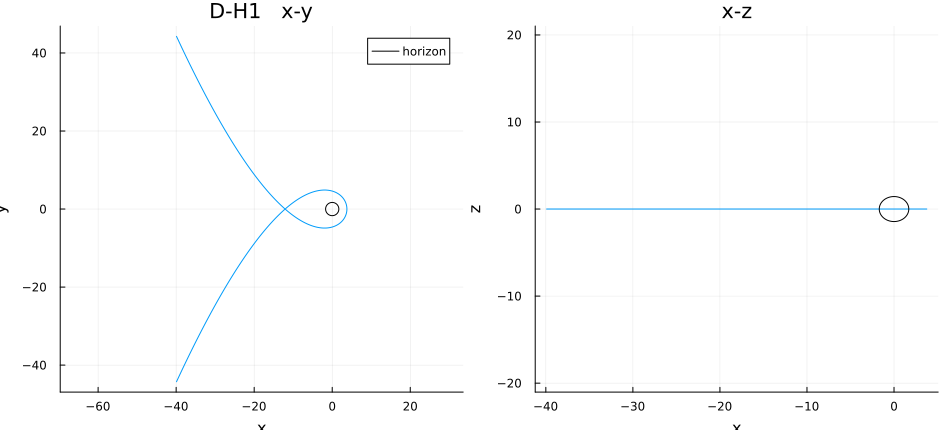

In [35]:
built = kg56_construct("D-H1")            # also :D_H1 or :K4
fx = built.example
println("parameters: a = ", fx.a, "  E = ", fx.E, "  Lz = ", fx.Lz, "  Q = ", fx.Q, "   motion: ", KG56_MOTION_LABELS[fx.case_id])
plot_member(built.member; title=fx.name)

**Figure.** The catalogue example D-H1 (its $a, E, L_z, Q$ are printed above the figure). Left: the $x$–$y$ plane; right: the $x$–$z$ plane, with $x = \sqrt{r^2+a^2}\sin\theta\cos\phi$, $y = \sqrt{r^2+a^2}\sin\theta\sin\phi$, $z = r\cos\theta$ (units of $M$, spin along $z$); the black curve is the outer horizon $r = r_+$.

In [36]:
# The separate Catalog notebook contains the complete set.
println("Catalogue examples: ", length(KG56_EXAMPLES))

Catalogue examples: 56


## 11. Batch sampling and performance

`kerr_geo_sample(m, λs)` evaluates `t, r, theta, phi, tau, ut, ur, utheta, uphi` at many Mino times in one call, behind a function barrier. After compilation for the relevant member types, the first evaluation of $t$, $\phi$, $\tau$, $v$ or $\psi$ builds the member's radial Chebyshev tables in less than a millisecond in the measured examples; after that the nine quantities together cost a few microseconds per point (timed below). Loading and first specialization add compilation cost.

In [37]:
m = fam.Plunge
lo, hi = m.Domain.mino
λs = collect(range(lo, hi; length=2^14 + 2)[2:end-1])
kerr_geo_sample(m, λs[1:10]);
out = kerr_geo_sample(m, λs);
microseconds = 1e6 * minimum(@elapsed(kerr_geo_sample(m, λs)) for _ in 1:5) / length(λs)
@printf("Samples: %d\nWarm evaluation: %.3f microseconds per point\n", length(out.r), microseconds)

Samples: 16384
Warm evaluation: 1.133 microseconds per point


## 12. How the trajectories are computed

- **$r(\lambda)$, $z(\lambda)$**: a formula in Jacobi elliptic (or elementary) functions for each root structure. Periodic polar motion can be written as $z = s\sqrt{A}\,J(u_0 + \omega\lambda \,|\, m)$, where $s=\pm1$ sets the sign, $A$ is the squared amplitude of that representation, $u_0$ is its initial phase, $\omega$ is the phase rate with respect to Mino time, $m$ is the elliptic parameter, and $J \in \{\mathrm{sn}, \mathrm{cn}, \mathrm{dn}, \mathrm{cd}\}$ is the selected Jacobi function.
- **$t, \phi, \tau$ (and $v, \psi$)**: the rates of the Carter equations split into a part in $r$ and a part in $z$. Each part is sampled along the analytic solution, fitted by piecewise Chebyshev series and integrated exactly into a stored primitive; an evaluation is then a piece lookup and one polynomial evaluation.
  - For periodic polar motion, the polar part uses the symmetry of $z^2$ in the phase $u=u_0+\omega\lambda$ and is fitted once on $[0,K(m)]$, with $K(m)$ the complete elliptic integral of the first kind; nonperiodic limits are handled separately. Near the axis the $L_z/(1-z^2)$ spike is integrated analytically.
  - The radial part is split by endpoint type: next to a horizon the regular kernel $(P - \sqrt R)/\Delta = K_r/(P + \sqrt R)$, $K_r = r^2 + (L_z - aE)^2 + Q$, separates the logarithms of $r_*$ and $\phi_H$ analytically (so $v = t + r_*$ is finite on the horizon); towards infinity the variable is $q = \sqrt{r_s/r}$ ($r_s$ the radius where that segment starts) with the leading terms integrated in closed form; next to a repeated root the root is divided out first.
- **Tables**: building a member classifies the constants, finds the roots and fits the polar table (an eccentric Stable member also fits its radial period, which gives $\Upsilon_t$ and $\Upsilon_\phi$); the other radial tables are built on the first evaluation of $t$, $\phi$, $\tau$, $v$ or $\psi$. `m.Status.spectral` reports the accuracy they reached.

The polar metadata shows which Jacobi function, elliptic parameter $m$ and phase rate $\omega$ are used:

In [38]:
m = fam.Plunge
println("Radial formula: ", m.Status.formula_family)
println("Polar sector: ", m.Roots.polar.sector)

Radial formula: FF05
Polar sector: pendular


## 13. Accuracy limits

Accuracy depends on both Float64 input conditioning and rounding in intermediate calculations. The spectral fit estimate is not a bound on the total coordinate error (see the documentation for details):

- **Polar phase**: the phase $u_0 + \omega\lambda$ carries an absolute rounding error of about $\epsilon|\omega\lambda|$, which reaches order one at $|\lambda| \sim 1/(\omega\,\epsilon)$.
- **Nearly parabolic stable orbits**: after one radial period $t$ is known to `m.Status.precision.t_ulp_per_period` at best (about $10^3 M$ for $|E-1| \sim 10^{-13}$).
- **Near the spin axis**: on the narrow azimuthal spike of an orbit with small $L_z$, $\phi(\lambda)$ has an absolute error of about $|d\phi/d\lambda|\cdot \mathrm{ulp}(\lambda)$ from rounding $\lambda$; period increments measured off the spike agree to $\sim 10^{-15}$ in the tested examples, not uniformly for all inputs.
- **Far from the hole**: for $E > 1$, $\lambda$ resolves radii only up to $\sim 10^{16}$; radius-based increments `m.Trajectory.radial_*_increment(r1, r2)` avoid this particular resolution limit.
- **Very close to the horizon**: intermediate-radius rounding is amplified in divergent Boyer–Lindquist coordinates. For K8 with $(a,E,L_z,Q)=(0.7,1,-0.7,16)$, independent quadrature finds relative errors in $t$ of about $8\times10^{-10}$ at $\lambda=-10^{-8}$ and $5\times10^{-8}$ at $\lambda=-10^{-10}$. These are not error estimates for $v$ or $\psi$.
- **Very small nonzero spin**: cancellation in some combinations approaching the Schwarzschild limit can also reduce precision; this is an implementation limitation, not just input conditioning.